# Clustering Energy Analysis

Thin runner notebook for LRK/xKV clustering comparisons across keys and values, with independent cells for each tensor and clustering axis.

In [ ]:
from pathlib import Path
import sys

import torch


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "utils").is_dir():
            return path
    raise RuntimeError("Could not find repo root containing ./utils")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from analysis.utils import display_case_result, load_kv_dump, run_analysis_case

%load_ext autoreload
%autoreload 2

/home/m84366023/miniconda3/envs/pem-llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
kv_dump_path = (
    repo_root
    / "results/kv_dumps/meta-llama_Llama-3.1-8B-Instruct/niah_multiquery_raw_kv.pt"
)
loaded = load_kv_dump(kv_dump_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

raw_keys = loaded["raw_keys"]
keys = loaded["keys"].to(device)
values = loaded["values"].to(device)
prompt_len = loaded["prompt_len"]
rope_theta = loaded["rope_theta"]

keys.shape, values.shape, prompt_len, rope_theta

Using device: cuda


(torch.Size([32, 1, 8, 3770, 128]),
 torch.Size([32, 1, 8, 3770, 128]),
 3770,
 500000.0)

In [3]:
show_detail_tables = False

kmeans_cfg = {
    "n_clusters": 3,
    "kmeans_cluster_size": 512,
    "kmeans_n_iter": 16,
    "kmeans_init": "kmeans++",
    "kmeans_dtype": torch.float32,
}

decomposition_cfg = {
    "decomposition_method": "svd",
    "rank_selection": "comp_ratio",
    "comp_ratio": 1.5,
    "energy_threshold": 0.95,
    "decomp_n_iter": 3,
    "decomp_lr": 1e-2,
}

lrk_mode = "per_head"  # "avg_heads" or "per_head"
include_lrk_head_breakdown = False
prefix_end = prompt_len
local_window = 0

xkv_layer_group_size = 4
xkv_num_layers = keys.size(0)

## Keys, Row Clustering

,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,keys_lrk_rows,256,0.232370,0.220200,0.095618,0.101767,0.034217,0.483254
1,keys_xkv_rows,40,0.238274,0.241714,0.066206,0.068102,0.113051,0.375000
2,keys_lrk_rows_n_clusters_1,256,0.315142,0.304667,0.092470,0.098651,0.074367,0.558442
3,keys_xkv_rows_n_clusters_1,40,0.311980,0.306936,0.049976,0.052382,0.173713,0.473684


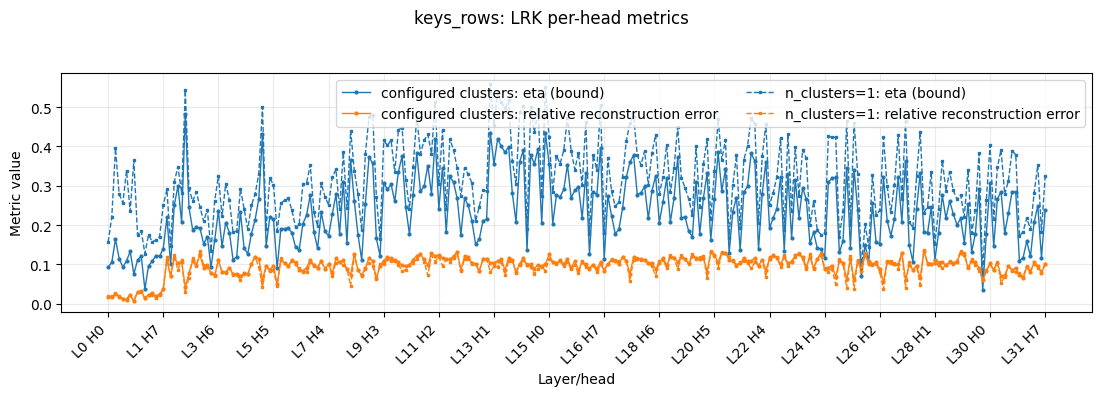

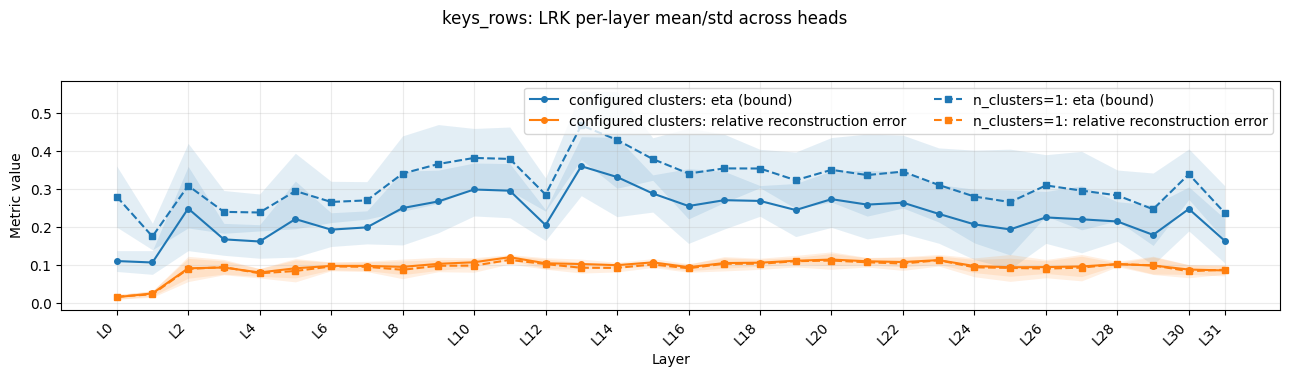

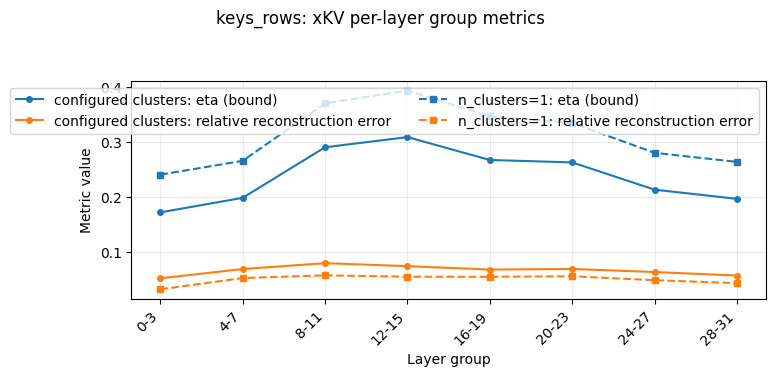

In [4]:
keys_rows = run_analysis_case(
    keys,
    tensor_name="keys",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

display_case_result(keys_rows, show_detail_tables=show_detail_tables)

## Values, Row Clustering

,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,values_lrk_rows,256,0.785898,0.812603,0.310529,0.313681,0.140306,0.963731
1,values_xkv_rows,40,0.816907,0.834743,0.192596,0.193835,0.474490,0.888889
2,values_lrk_rows_n_clusters_1,256,0.891137,0.922806,0.342712,0.347312,0.213010,0.988571
3,values_xkv_rows_n_clusters_1,40,0.883943,0.905339,0.158842,0.156785,0.528061,0.944751


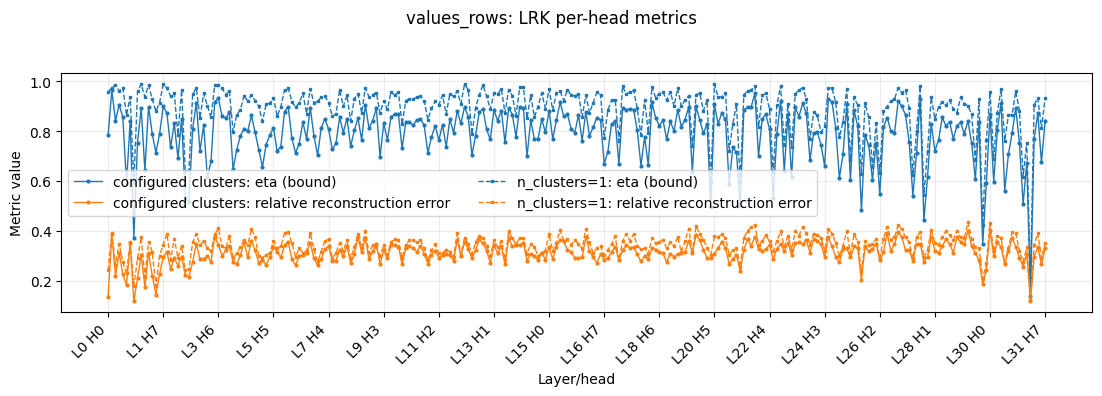

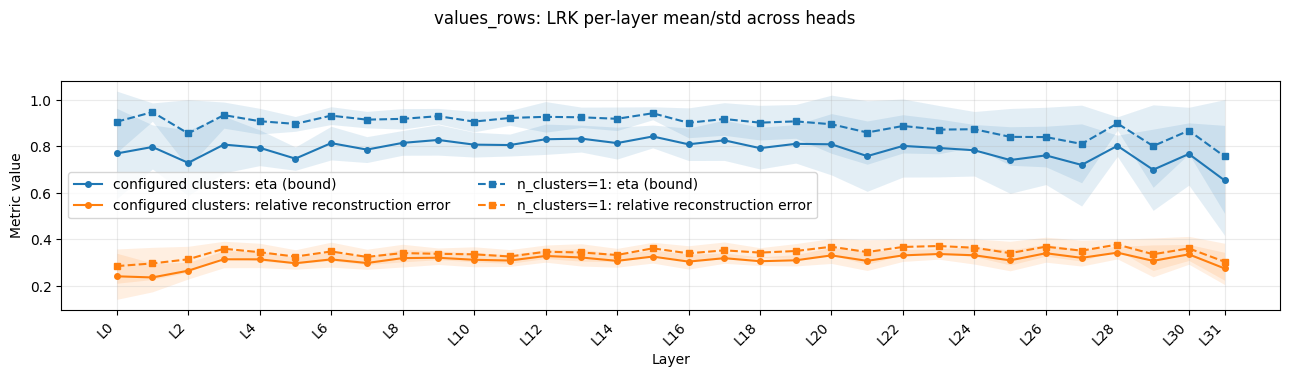

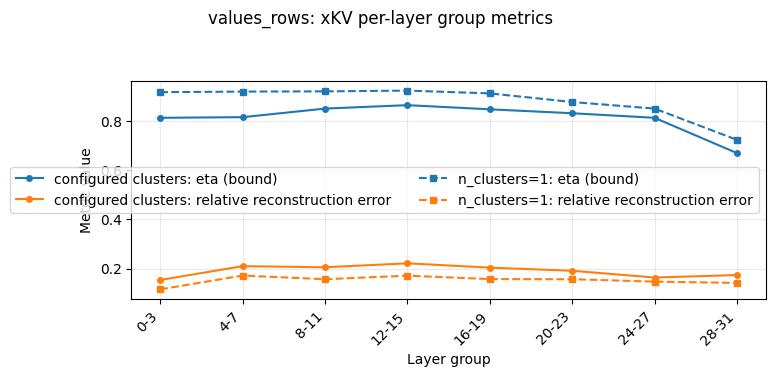

In [5]:
values_rows = run_analysis_case(
    values,
    tensor_name="values",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

display_case_result(values_rows, show_detail_tables=show_detail_tables)

## Keys, Column Clustering

,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,keys_lrk_cols,256,0.992539,0.993650,0.092476,0.098793,0.932039,1.000000
1,keys_xkv_cols,40,0.349501,0.343716,0.069244,0.071394,0.202206,0.493421
2,keys_lrk_cols_n_clusters_1,256,0.992539,0.993650,0.092476,0.098793,0.932039,1.000000
3,keys_xkv_cols_n_clusters_1,40,0.999446,1.000000,0.049988,0.052382,0.992481,1.000000


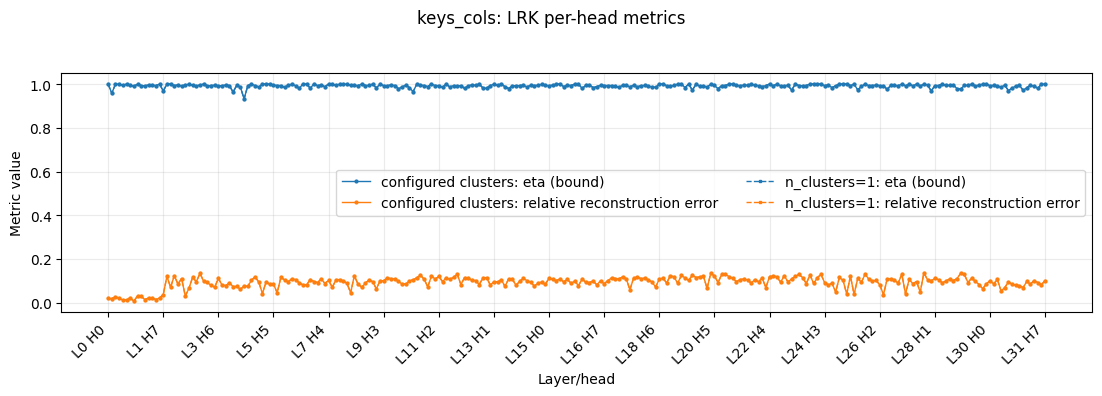

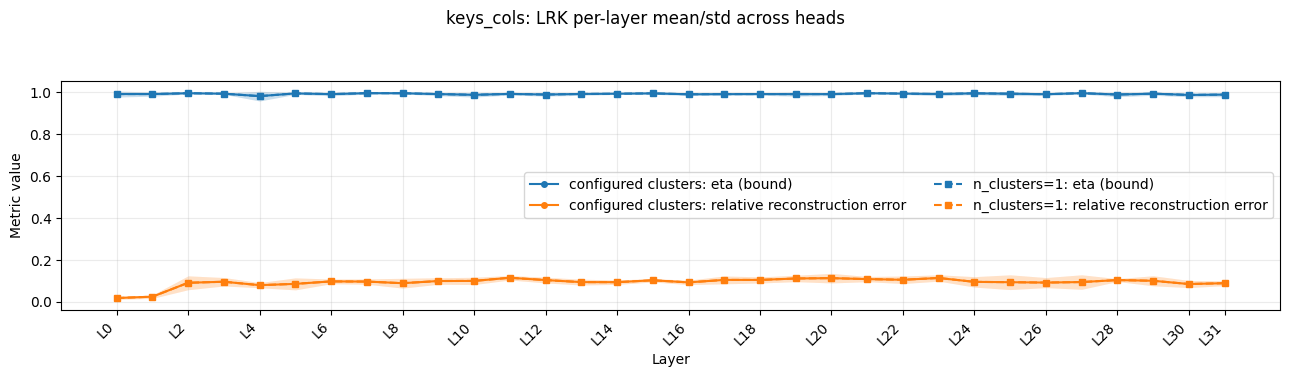

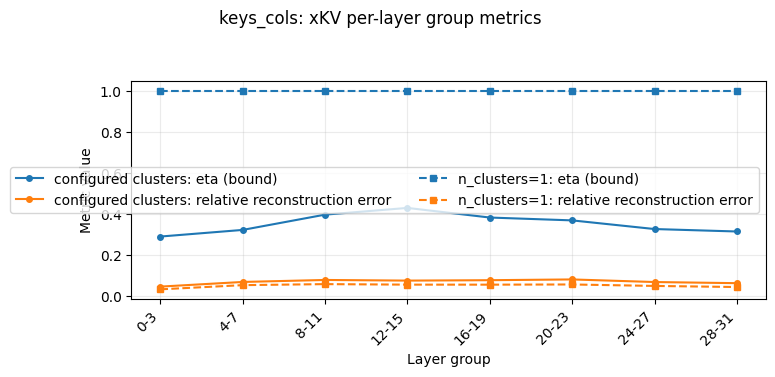

In [6]:
keys_cols = run_analysis_case(
    keys,
    tensor_name="keys",
    cluster_axis="cols",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

display_case_result(keys_cols, show_detail_tables=show_detail_tables)

## Values, Column Clustering

In [ ]:
values_cols = run_analysis_case(
    values,
    tensor_name="values",
    cluster_axis="cols",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

display_case_result(values_cols, show_detail_tables=show_detail_tables)